In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
import torch
import numpy as np
sys.path.append(os.path.abspath('../scripts'))
from supporting.load_data import load_data, build_data_loaders, x_scale, y_scale, y_unscale
from sklearn import metrics
from torch import nn, optim
import torch.nn.functional as F

In [21]:
def get_device():
    ''' function to get the device the NN is running on, CPU or GPU
    '''
    if torch.cuda.is_available():
        device = torch.device("cuda:0")
    else: 
        device = torch.device("cpu")
        
    return device

In [22]:
config = {
    "model_type": "skip-mini",
    "input_shape": 4,
    "amplitude_shape": 36,
    "data_dir": "/scratch/hakula/dataset",
    "seed": 42,
    "var_y": [
        "y5",
        "y6"
    ],
    "use_MC_sample": False,
    "train-sample-size": 10000000,
    "validate-sample-size": 500000,
    "test-sample-size": 500000,
    "activation": "leaky_relu",
    "width": 30,
    "depth": 12,
    "skip_block_layers": 5,
    "lr_decay_type": "plateau",
    "initial_lr": 0.001,
    "lr_patience": 10,
    "lr_factor": 0.8,
    "lr_delta": 7e-05,
    "batch_size": 1024,
    "steps_per_epoch": 2400,
    "early_stopping_start_epoch": 150,
    "patience": 25,
    "loss": "huber",
    "base_directory": "../models/",
    "epochs": 2000,
    "model-uuid": "UUID",
    "train-samples-used": 6,
    "validate-samples-used": 6,
    "test-samples-used": 6,
    "n_targets": 2
}

In [56]:
config = {
    "model_type": "skip-mini",
    "input_shape": 4,
    "amplitude_shape": 36,
    "data_dir": "/scratch/hakula/dataset",
    "seed": 42,
    "var_y": [
        "y5",
        "y6"
    ],
    "use_MC_sample": False,
    "train-sample-size": 10000000,
    "validate-sample-size": 500000,
    "test-sample-size": 500000,
    "activation": "leaky_relu",
    "width": 30,
    "depth": 12,
    "skip_block_layers": 5,
    "lr_decay_type": "plateau",
    "initial_lr": 0.001,
    "lr_patience": 10,
    "lr_factor": 0.8,
    "lr_delta": 7e-05,
    "batch_size": 1024,
    "steps_per_epoch": 2400,
    "early_stopping_start_epoch": 150,
    "patience": 25,
    "loss": "huber",
    "base_directory": "../models/",
    "epochs": 2000,
    "model-uuid": "UUID",
    "train-samples-used": 6,
    "validate-samples-used": 6,
    "test-samples-used": 6,
    "n_targets": 2
}

In [23]:
torch.set_default_dtype(torch.float64)

In [52]:
class MyDataset(torch.utils.data.Dataset):
    '''Class to convert dataframe to torch tensor'''
    def __init__(self, x, y, config):
        x = x.copy(deep=True)
        y = y.copy(deep=True)

        # Vectorized scaling (if applicable)
        x['x1'] = x_scale(x['x1'])  # Or use apply if x_scale isn't vectorized

        # Number of targets
        config['n_targets'] = y.shape[1]

        for column in y.columns:
            y[column] = y[column].apply(y_scale)

        device = get_device()
        self.x = torch.tensor(x.values, dtype=torch.float64).to(device)
        self.y = torch.tensor(y.values, dtype=torch.float64).reshape(-1, config['n_targets']).to(device)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

df, spark = load_data(config)

x_cols = ['x1', 'x2', 'x3', 'x4']
y_cols = config["var_y"]
x_train = df["train"][x_cols]
y_train = df["train"][y_cols]
x_val = df["validate"][x_cols]
y_val = df["validate"][y_cols]
x_test = df["test"][x_cols]
y_test = df["test"][y_cols]

train_dataset = MyDataset(x_train, y_train, config)
val_dataset   = MyDataset(x_val, y_val, config)
test_dataset  = MyDataset(x_test, y_test, config)

# load the data into torch tensor batches
batch_size = config["batch_size"]
numworkers = 4 if get_device().type == 'cpu' else 0

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=numworkers, drop_last=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=True, num_workers=numworkers, drop_last=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=numworkers, drop_last=True)


[]
['y1', 'y2', 'y3', 'y4', 'y5', 'y6', 'y7', 'y8', 'y9', 'y10', 'y11', 'y12', 'y13', 'y14', 'y15', 'y16', 'y17', 'y18', 'y19', 'y20', 'y21', 'y22', 'y23', 'y24', 'y25', 'y26', 'y27', 'y28', 'y29', 'y30', 'y31', 'y32', 'y33', 'y34', 'y35', 'y36']


25/06/26 22:57:34 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


In [26]:
model_path = "/home/hakula/qqzz4l-NN/models/skip-mini_a18ff108_30_12_5/a18ff108.best_weights.pt"

In [27]:
def test_model(model, test_data, config):
    ''' function for testing the model
        arguments:
            model: the pytorch model to nbe trained
            test_data: the test data loader
            config: the configurations file
        returns:
            the absolute error
            the R2 score
    '''
    
    for i, data in enumerate(test_data):
        
        # forward prop
        x, y = data
        y_p = model(x)
        
        # store data
        if i == 0:
            x_test = x.cpu().detach().numpy()
            y_test = y.cpu().detach().numpy()
            y_pred = y_p.cpu().detach().numpy()
        else: 
            x_test = np.vstack((x_test, x.cpu().detach().numpy()))
            y_test = np.vstack((y_test, y.cpu().detach().numpy()))
            y_pred = np.vstack((y_pred, y_p.cpu().detach().numpy()))
        
    
    # accuracy
    y_test = np.array(y_test).reshape(-1, config['n_targets'])
    y_pred = np.array(y_pred).reshape(-1, config['n_targets'])
    abs_score = (1 - np.mean(np.abs((y_pred - y_test)/y_test)))*100
    r2_score = metrics.r2_score(y_test, y_pred)*100
    
    # save test results
    df_pred = pd.DataFrame(x_test, columns=['x'+str(i+1) for i in range(config['input_shape'])])
    
    # unscale the target
    scaled_cname = [s + '_scaled' for s in config['var_y']]
    df_pred = pd.concat([df_pred, pd.DataFrame(y_test, columns=scaled_cname)], axis=1)
    for col in df_pred.columns[4:]:
        df_pred[col[:-7]] = df_pred[col].apply(lambda y: y_unscale(y))
    # y_test_real = pd.DataFrame(np.vectorize(y_unscale)(y_test), columns=config['var_y']) # 
    # df_pred = pd.concat([df_pred, y_test_real], axis=1)
    y_test_real = df_pred.iloc[:,-config['n_targets']:].to_numpy()
    
    # stuff in the scaled predictions
    pred_cname = [s + '_scaled_pred' for s in config['var_y']]
    df_pred = pd.concat([df_pred, pd.DataFrame(y_pred, columns=pred_cname)], axis=1)
    
    # stuff in the unscaled predictions
    pred_cname = [s + '_pred' for s in config['var_y']]
    for col in df_pred.columns[-config['n_targets']:]:
        df_pred[col[:-12]+'_pred'] = df_pred[col].apply(lambda y: y_unscale(y))
    # y_pred_real = pd.DataFrame(np.vectorize(y_unscale)(y_pred), columns=pred_cname) # .apply(lambda y: y_unscale(y))
    # df_pred = pd.concat([df_pred, y_pred_real], axis=1)
    y_pred_real = df_pred.iloc[:,-config['n_targets']:].to_numpy()
    
    # calculate the deltas for the scaled and unscaled targets
    scaled_delta_cname = ['scaled_delta_' + s for s in config['var_y']]
    df_pred = pd.concat([df_pred, pd.DataFrame((y_pred - y_test)/y_test*100, columns=scaled_delta_cname)], axis=1)
    delta_cname = ['delta_' + s for s in config['var_y']]
    df_pred = pd.concat([df_pred, pd.DataFrame((y_pred_real - y_test_real)/y_test_real*100, columns=delta_cname)], axis=1)
    
    #same the whole dataframe
    #df_pred.to_csv(config['directory']+'/test-results-'+config['model-uuid']+'-'+f'{abs_score:.6f}-{r2_score:.6f}.csv')
    
    # # plot all the scaled and real deltas
    # for c in scaled_delta_cname:
    #     make_error_plot(config, df_pred, col=c)
    # for c in delta_cname:
    #     make_error_plot(config, df_pred, col=c)
        
    test_metrics = {}
    test_metrics['r2'] = {}
    test_metrics['abs_score'] = {}
    num_vars = len(config['var_y'])
    base_length = config['input_shape'] + num_vars
    for i in range(base_length, base_length + num_vars):
        test = df_pred.iloc[:,i].values
        pred = df_pred.iloc[:,i + 2 * num_vars].values
        test_metrics['r2'][config['var_y'][i - base_length]] = metrics.r2_score(test, pred)*100
        test_metrics['abs_score'][config['var_y'][i - base_length]] = 100 - np.abs(df_pred.iloc[:,i + 4 * num_vars]).mean()
    
    test_metrics['r2']['model'] = r2_score
    test_metrics['abs_score']['model'] = abs_score
    
    return test_metrics, df_pred


In [28]:
def get_activation(activation_str):
    if activation_str == 'leaky_relu':
        return nn.LeakyReLU()
    elif activation_str == 'relu':
        return nn.ReLU()
    if activation_str == 'softplus':
        return nn.Softplus()
    if activation_str == 'swish':
        return nn.SiLU()
    if activation_str == 'sigmoid':
        return nn.Sigmoid()
    if activation_str == 'tanh':
        return nn.Tanh()
    if activation_str == 'prelu':
        return nn.PReLU()
    if activation_str == 'elu':
        return nn.ELU()

# Residual module (equivalent to 'module' in Keras)
class ResidualBlock(nn.Module):
    def __init__(self, in_dim, width, n_skip_layers, activation='swish'):
        super().__init__()
        layers = []
        orig_in_dim = in_dim
        for _ in range(n_skip_layers - 1):
            layers.append(nn.Linear(in_dim, width))
            layers.append(get_activation(activation))
            in_dim = width
        layers.append(nn.Linear(width, orig_in_dim))  # projection back to input dim
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return x + self.net(x)

# Full model (equivalent to 'model' in Keras)
class SkipModel(nn.Module):
    def __init__(self, input_dim, width, depth, n_skip_layers, output_dim, activation='swish'):
        super().__init__()
        self.input_layer = nn.Sequential(
            nn.Linear(input_dim, width),
            get_activation(activation)
        )
        self.res_blocks = nn.Sequential(*[
            ResidualBlock(in_dim=width, width=width, n_skip_layers=n_skip_layers, activation=activation) for _ in range(depth)
        ])
        self.output_layer = nn.Linear(width, output_dim)

    def forward(self, x):
        x = self.input_layer(x)
        x = self.res_blocks(x)
        return self.output_layer(x)


In [29]:
width = config['width']
depth = config['depth']
n_skip_layers = config['skip_block_layers']
activation = config['activation']

model = SkipModel(config["input_shape"], width, depth, n_skip_layers, len(y_cols), activation)
model.to(device=get_device())

SkipModel(
  (input_layer): Sequential(
    (0): Linear(in_features=4, out_features=30, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
  )
  (res_blocks): Sequential(
    (0): ResidualBlock(
      (net): Sequential(
        (0): Linear(in_features=30, out_features=30, bias=True)
        (1): LeakyReLU(negative_slope=0.01)
        (2): Linear(in_features=30, out_features=30, bias=True)
        (3): LeakyReLU(negative_slope=0.01)
        (4): Linear(in_features=30, out_features=30, bias=True)
        (5): LeakyReLU(negative_slope=0.01)
        (6): Linear(in_features=30, out_features=30, bias=True)
        (7): LeakyReLU(negative_slope=0.01)
        (8): Linear(in_features=30, out_features=30, bias=True)
      )
    )
    (1): ResidualBlock(
      (net): Sequential(
        (0): Linear(in_features=30, out_features=30, bias=True)
        (1): LeakyReLU(negative_slope=0.01)
        (2): Linear(in_features=30, out_features=30, bias=True)
        (3): LeakyReLU(negative_slope=0.01)
     

In [35]:
best_weights_path = model_path
model.load_state_dict(torch.load(best_weights_path, map_location=torch.device('cuda' if torch.cuda.is_available() else 'cpu')))

/tmp/ipykernel_32227/3790447714.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_weights_path, map_location=torch.device('cuda' if t

<All keys matched successfully>

In [36]:
test_metrics, df_pred = test_model(model, test_loader, config)

In [33]:
test_metrics

{'r2': {'y5': 73.52059761068325,
  'y6': 65.11295003793356,
  'model': 99.9297257891863},
 'abs_score': {'y5': 98.81574443787352,
  'y6': 98.86503816909607,
  'model': 99.28962779988962}}

# Eval code

# Error plots 

## h2 real and imaginary

In [37]:
# df_h2 = pd.read_csv('../models/skip-light-torch-4D-y5_y6-fe15fc3c--13-29-leaky_relu-1024-adam-exp-schedule-mse-val_mse-96.667286-99.840031/test-results-fe15fc3c-96.667286-99.840031.csv')
df_h2 = df_pred

In [38]:
df_h2

,x1,x2,x3,x4,y5_scaled,y6_scaled,y5,y6,y5_scaled_pred,y6_scaled_pred,y5_pred,y6_pred,scaled_delta_y5,scaled_delta_y6,delta_y5,delta_y6
0,0.000131,0.147431,0.774351,0.245984,-5.167388,5.236248,-174.455943,186.963621,-5.164296,5.235466,-173.914296,186.816524,-0.059834,-0.014951,-0.310478,-0.078677
1,0.000542,0.705441,0.511854,0.034134,5.032969,-5.069397,152.387746,-158.078358,5.033529,-5.070821,152.473722,-158.305015,0.011134,0.028086,0.056419,0.143383
2,0.000753,0.348233,0.460954,0.283262,4.168857,-4.184300,63.641536,-64.647520,4.169404,-4.187727,63.676865,-64.872904,0.013106,0.081910,0.055512,0.348635
3,0.000866,0.659904,0.123490,0.852356,5.413599,-5.481205,223.437810,-239.135900,5.411355,-5.478758,222.934899,-238.549070,-0.041438,-0.044639,-0.225079,-0.245396
4,0.000906,0.547915,0.649524,0.693039,5.148154,-5.184982,171.113443,-177.570199,5.146998,-5.185651,170.914612,-177.689816,-0.022453,0.012915,-0.116199,0.067363
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499707,0.858574,0.084713,0.169534,0.451104,-4.115073,0.524211,-60.256685,0.689126,-4.119528,0.535246,-60.530210,0.707868,0.108267,2.105025,0.453933,2.719727
499708,0.858653,0.315792,0.713225,0.709775,-2.779589,-1.419106,-15.112394,-3.133422,-2.778696,-1.419514,-15.098015,-3.135109,-0.032120,0.028754,-0.095145,0.053838
499709,0.858838,0.609794,0.212700,0.336352,-2.043512,-1.287358,-6.717664,-2.623202,-2.043194,-1.285214,-6.715215,-2.615443,-0.015527,-0.166513,-0.036447,-0.295763
499710,0.858842,0.432198,0.130247,0.729713,-2.497521,-1.491892,-11.152331,-3.445499,-2.498999,-1.491721,-11.170311,-3.444739,0.059197,-0.011461,0.161222,-0.022059


In [39]:
df_h2.describe()

,x1,x2,x3,x4,y5_scaled,y6_scaled,y5,y6,y5_scaled_pred,y6_scaled_pred,y5_pred,y6_pred,scaled_delta_y5,scaled_delta_y6,delta_y5,delta_y6
count,4.997120e+05,499712.000000,499712.000000,4.997120e+05,499712.000000,499712.000000,499712.000000,499712.000000,499712.000000,499712.000000,499712.000000,499712.000000,499712.000000,499712.000000,499712.000000,499712.000000
mean,4.992570e-01,0.499469,0.499598,4.991992e-01,-0.754574,-2.868337,-16.256098,-61.423110,-0.757645,-2.867944,-16.397839,-60.563010,0.033102,0.113312,0.155882,0.072078
std,2.884018e-01,0.288691,0.288807,2.883081e-01,3.558973,2.633590,247.092445,428.192222,3.558919,2.634412,218.779606,273.012839,65.450940,105.530869,72.815868,114.071692
min,1.461593e-07,0.000004,0.000001,1.887156e-09,-10.787503,-11.666206,-48411.017079,-116564.245685,-10.021551,-10.300026,-22505.318093,-29732.383644,-13422.257190,-7593.913518,-13786.969553,-14550.658617
25%,2.494522e-01,0.249476,0.249090,2.496178e-01,-3.252303,-4.732635,-24.849805,-112.594545,-3.254499,-4.733117,-24.906632,-112.649221,-0.031070,-0.051973,-0.115146,-0.195246
50%,4.990797e-01,0.499650,0.499897,4.984394e-01,-2.400150,-3.730105,-10.024829,-40.683500,-2.401654,-3.730589,-10.041425,-40.703680,0.033875,0.004100,0.113714,0.015122
75%,7.484917e-01,0.749424,0.749368,7.483340e-01,3.492573,-1.830020,31.870417,-5.234014,3.491064,-1.828597,31.820844,-5.225144,0.098590,0.064753,0.334594,0.229320
max,9.999942e-01,0.999998,0.999999,9.999981e-01,10.151488,7.795848,25628.215377,2429.490484,8.626613,7.321080,5577.153719,1510.835854,29289.252893,71800.025599,31348.020433,74061.531286


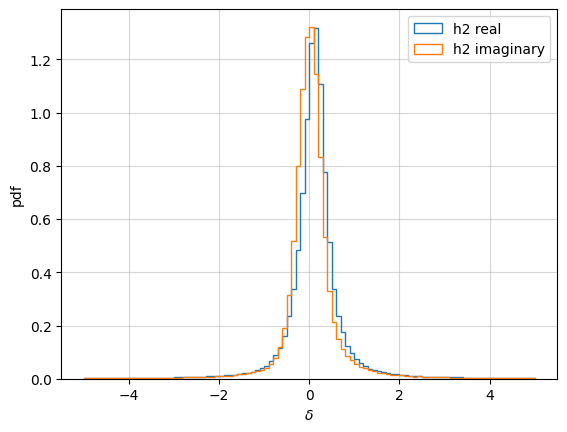

In [40]:
plt.hist(df_h2[abs(df_h2.delta_y5) < 5].delta_y5, bins=100, histtype='step', label='h2 real', density=True)
plt.hist(df_h2[abs(df_h2.delta_y6) < 5].delta_y6, bins=100, histtype='step', label='h2 imaginary', density=True)
plt.grid('dotted', alpha=0.5)
plt.xlabel(r'$\delta$')
plt.ylabel(r'pdf')
plt.legend()
plt.show()

In [46]:
df_h2[abs(df_h2.scaled_delta_y6) < 5].scaled_delta_y6

0        -0.014951
1         0.028086
2         0.081910
3        -0.044639
4         0.012915
            ...   
499707    2.105025
499708    0.028754
499709   -0.166513
499710   -0.011461
499711   -0.064202
Name: scaled_delta_y6, Length: 495460, dtype: float64

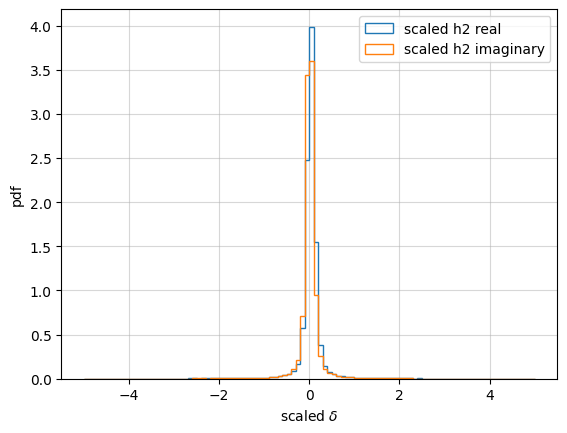

In [50]:
plt.hist(df_h2[abs(df_h2.scaled_delta_y5) < 5].scaled_delta_y5, bins=100, histtype='step', label='scaled h2 real', density=True)
plt.hist(df_h2[abs(df_h2.scaled_delta_y6) < 5].scaled_delta_y6, bins=100, histtype='step', label='scaled h2 imaginary', density=True)
plt.grid('dotted', alpha=0.5)
plt.xlabel(r'scaled $\delta$')
plt.ylabel(r'pdf')
plt.legend()
plt.show()